## Rossmann Store Sales Analytics: Understanding Store Performance, Promotions, Customers and Sales Trends

### Project Overview
Rossmann operates over 3,000 drug stores in 7 European countries. In this project, we are analyzing historical sales data to understand the factors that influence store performance.

In [54]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import plotly.express as px
import plotly.graph_objects as go

In [55]:
train = pd.read_csv('C:/Users/John.Kariuki.MRCT/Downloads/Data Analytics and Data Apps/Rossman Sales Analysis/Data/train.csv', low_memory=False)
test =  pd.read_csv('C:/Users/John.Kariuki.MRCT/Downloads/Data Analytics and Data Apps/Rossman Sales Analysis/Data/test.csv')
store =  pd.read_csv('C:/Users/John.Kariuki.MRCT/Downloads/Data Analytics and Data Apps/Rossman Sales Analysis/Data/store.csv')

In [56]:
# Preview our Data
summary_df = pd.DataFrame(
    {
        'Dataset': ['train.csv', 'store.csv'],
        'Rows': [len(train), len(store)],
        'Columns': [len(train.columns), len(store.columns)]
    }
)
display(summary_df)
display(train.head())
display(store.head())


,Dataset,Rows,Columns
0,train.csv,1017209,9
1,store.csv,1115,10


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [57]:

# data quality audit
def quality_audit(df, name):
    print(f'---Data Quality Audit {name}')

    audit = pd.DataFrame(
        {
            'Missing Values': df.isnull().sum(),
            'Missing %': (df.isnull().sum()/len(df)) * 100,
            'Data Types': df.dtypes,
            'Unique Values': df.nunique()
        }
    )

    display(audit[audit['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False))
    print(f"Duplicate Rows: {df.duplicated().sum()}")

quality_audit(train, 'Train Data')
quality_audit(store, 'Store Data')
  
  
   

---Data Quality Audit Train Data


,Missing Values,Missing %,Data Types,Unique Values


Duplicate Rows: 0
---Data Quality Audit Store Data


,Missing Values,Missing %,Data Types,Unique Values
Promo2SinceYear,544,48.789238,float64,7
Promo2SinceWeek,544,48.789238,float64,24
PromoInterval,544,48.789238,str,3
CompetitionOpenSinceMonth,354,31.748879,float64,12
CompetitionOpenSinceYear,354,31.748879,float64,23
CompetitionDistance,3,0.269058,float64,654


Duplicate Rows: 0


### Data Cleaning

In [58]:
# Convert date to datetime
train['Date'] = pd.to_datetime(train['Date'])

In [59]:
# Handle missing competition Distance (Fill with median competition distance)
store['CompetitionDistance'] =store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())

In [60]:
# Handle promo2 missing values
promo2_cols = ['Promo2SinceYear', 'Promo2SinceWeek', 'PromoInterval']

for col in promo2_cols:
  store[col] =store[col].fillna(0)
    #store['PromoInterval'] =store['promoInterval'].fillna(0)

In [61]:
# Handle missing competition open dates
store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(0)
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(0)

## Merging Data and analytical Grain

In [62]:
# record rows before merge
len(train)

1017209

In [63]:
# perform a left join
df = train.merge(store,on='Store', how='left')

In [64]:
# see the rows after merge
len(df)

1017209

In [65]:
# unmatched stores
print(f'Unmatched stores: {df['StoreType'].isnull().sum()}')

Unmatched stores: 0


## Feature Engineering

In [66]:
# Time hierachy features
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.month_name()
df['WeekofYear'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day
df['DayofWeek_Name'] = df['Date'].dt.day_name()


In [67]:
# Business Date Features
df['is_weekend'] = df['DayOfWeek'].isin([6,7]).astype(int)
df['is_Month_Start'] = df['Date'].dt.is_month_start.astype(int)
df['is_Month_End'] = df['Date'].dt.is_month_end.astype(int)

#### Promo, Customer, Store, & competition Features

In [68]:
# Customer Feature: Sales per Customer (Avoid division by zero error)
df['sales Per Customer'] = np.where(df['Customers']>0,df['Sales']/df['Customers'],0)

In [69]:
# Store perfomance summary
Store_summary = df[df['Open'] == 1].groupby('Store').agg(
    Total_Sales = ('Sales', 'sum'),
    Avg_Daily_Sales = ('Sales', 'mean'),
    Total_Customers = ('Customers', 'sum'), 
    Avg_Sales_Per_Customer = ('Customers', 'mean'),
    Promo_Rate = ('Promo', 'mean')
).reset_index()





In [70]:
Store_summary.head()

,Store,Total_Sales,Avg_Daily_Sales,Total_Customers,Avg_Sales_Per_Customer,Promo_Rate
0,1,3716854,4759.096031,440523,564.049936,0.448143
1,2,3883858,4953.900510,457855,583.998724,0.451531
2,3,5408261,6942.568678,584310,750.077022,0.449294
3,4,7556507,9638.401786,1036254,1321.752551,0.450255
4,5,3642818,4676.274711,418588,537.340180,0.450578


In [71]:
# Rank stores by total sales
Store_summary['Rank'] = Store_summary['Total_Sales'].rank(ascending=False)

#### Advanced Series and Sales Change Features

In [72]:
# Sort by the store and date
df.sort_values(by=['Store', 'Date'])

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Quarter,Month,MonthName,WeekofYear,Day,DayofWeek_Name,is_weekend,is_Month_Start,is_Month_End,sales Per Customer
1016095,1,2,2013-01-01,0,0,0,0,a,1,c,...,1,1,January,1,1,Tuesday,0,1,0,0.000000
1014980,1,3,2013-01-02,5530,668,1,0,0,1,c,...,1,1,January,1,2,Wednesday,0,0,0,8.278443
1013865,1,4,2013-01-03,4327,578,1,0,0,1,c,...,1,1,January,1,3,Thursday,0,0,0,7.486159
1012750,1,5,2013-01-04,4486,619,1,0,0,1,c,...,1,1,January,1,4,Friday,0,0,0,7.247173
1011635,1,6,2013-01-05,4997,635,1,0,0,1,c,...,1,1,January,1,5,Saturday,1,0,0,7.869291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,1115,1,2015-07-27,10712,608,1,1,0,1,d,...,3,7,July,31,27,Monday,0,0,0,17.618421
4459,1115,2,2015-07-28,8093,500,1,1,0,1,d,...,3,7,July,31,28,Tuesday,0,0,0,16.186000
3344,1115,3,2015-07-29,7661,473,1,1,0,1,d,...,3,7,July,31,29,Wednesday,0,0,0,16.196617
2229,1115,4,2015-07-30,8405,502,1,1,0,1,d,...,3,7,July,31,30,Thursday,0,0,0,16.743028


In [73]:
# Calculate 7-day rolling average sales per store
df['7D_Rolling_Sales'] = df.groupby('Store')['Sales'].transform(lambda x: x.rolling(window=7,min_periods=1).mean())

In [74]:
# Calculate day_over_day percentage change (only for open stores to avoid artificial 100% drops)
df_open = df[df['Open']== 1].copy()
df_open['Daily_Sales_pct_change'] = df_open.groupby('Store')['Sales'].pct_change()

### Exploratory Data Analysis(EDA)

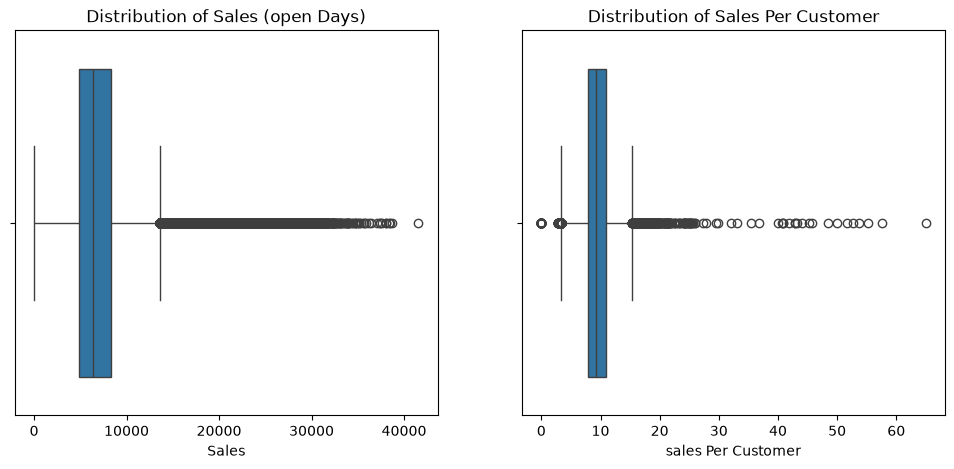

In [75]:
# Outlier Analysis
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x=df_open['Sales'])
plt.title('Distribution of Sales (open Days)')

plt.subplot(1,2,2)
sns.boxplot(x=df_open['sales Per Customer'])
plt.title('Distribution of Sales Per Customer')
plt.savefig('outlieranalysis.png')
plt.show()

1. Both overall daily sales and sales per customer exhibit a heavy rightward skew, characterized by a long tail of high_value outliers extending far beyond the upper whiskers.

2. For total daily sales on open days, the central 50% of the data is tightly concentrated, yet the business experiences a massive, dense volume of extremen revenue spikes that can push past 40,000

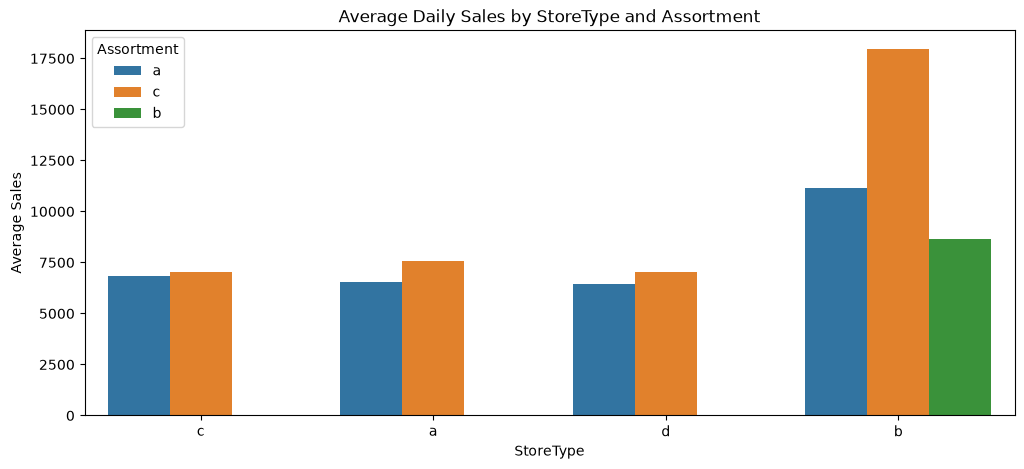

In [76]:
# which storetypes have different sales patterns?
plt.figure(figsize=(12,5))
sns.barplot(data = df_open, x='StoreType', y='Sales', hue='Assortment',
            errorbar=None, estimator =np.mean)
plt.title('Average Daily Sales by StoreType and Assortment')
plt.ylabel('Average Sales')
plt.savefig('Storetype.png')
plt.show()

1. Store Tybe 'b' has a drastically different and significant higher sales pattern compared to the rest

2. Store types 'a','c', and 'd' perform very similary to one another, with average daily      sales hovering between roughly 6,000 and 8,000.

3. In contrast, Store Type 'b' generates over 10,000 in average sales for its lowest_performing shared category and nearly 18,000 in its highest.

4. Additionally, Store Type 'b' is the only store type that sells Assorted 'b' (the green bar)

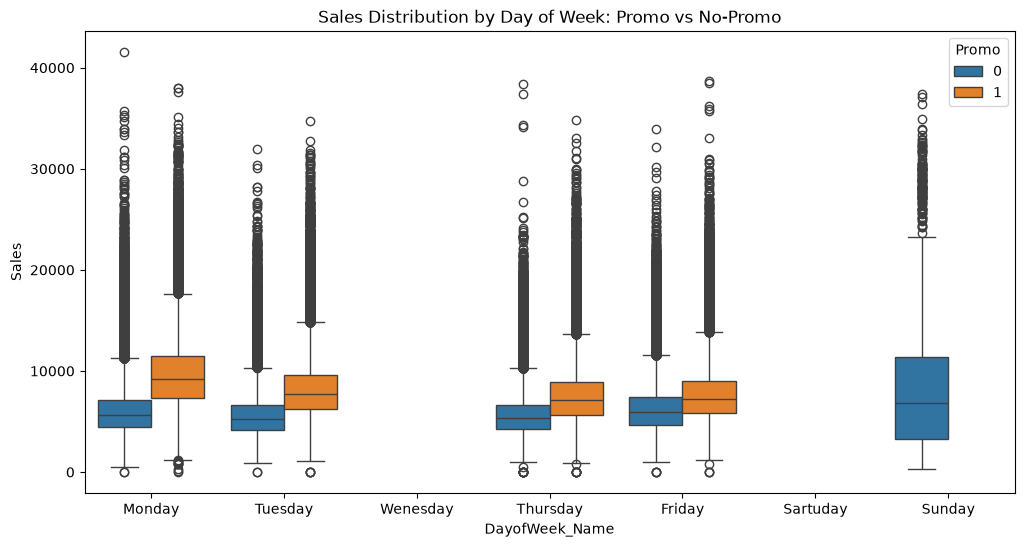

In [77]:
# How do promotions relate to sales across different days of the week?
plt.figure(figsize=(12,6))
sns.boxplot(data=df_open, x='DayofWeek_Name', y='Sales', hue='Promo',
            order=['Monday', 'Tuesday', 'Wenesday', 'Thursday', 'Friday', 'Sartuday', 'Sunday'])

plt.title('Sales Distribution by Day of Week: Promo vs No-Promo')
plt.savefig('promoanalysis.png')
plt.show()

1. Promotions consistently drive higher sales volume across the standard workweek, lifting both the median and the entire interquartile range from Monday through Friday compared to non-promotional days.

2. The business restricts this promotional strategy exclusively to weekdays, evidenced by the complete absence of active promotions (orange boxes) on Saturdays and Sundays.

3. Monday acts as the strongest sales day of the standard workweek, showing the highest median sales for both promotional and non-promotional categories.

4. Non-promotional baseline sales gradually taper off as the week progresses from Monday to Saturday.

5. Sunday displays a highly unique non-promotional sales distribution, featuring a much wider interquartile range and a higher median than any other non-promotional day.

6. Every day of the week exhibits a dense concentration of extreme high-value outliers extending far above the upper whiskers, indicating that certain stores or specific calendar events drive massive revenue spikes regardless of the standard weekly rhythm.

In [78]:

# Interactive Visualization (plotly)
# Aggregate monthly sales across all stores for time-series viewing
monthly_sales = df_open.groupby(['Year', 'Month', 'MonthName'])['Sales'].sum().reset_index()

monthly_sales['Date'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' +
                                       monthly_sales['Month'].astype(str) + '-01')

fig = px.line(monthly_sales, x='Date', y='Sales', markers=True,
    title='Total Rossmann Sales Over Time',
    labels={'Sales': 'Total Sales (€)'})

fig.update_layout(hovermode='x unified')

fig.show()

1. Strong Year-End Seasonality: Total sales exhibit a massive spike at the end of the year, visibly peaking at well over 220 million euros just before January 2014.

2. Mid-Year Sales Dips: There is a recurring trend of lower sales during the summer months, with a particularly sharp trough occurring shortly after July 2014, where sales dropped below 160 million euros.

3. Cyclical Volatility: The time series displays consistent month-to-month volatility, characterized by sharp, regular peaks and valleys that dictate the short-term sales rhythm throughout each year.

4. 2015 Recovery Trend: Following the significant dip in mid-2014, total sales show a distinct recovery trajectory, trending steadily upward through the first half of 2015 and crossing back over the 200 million euro mark just before July 2015.

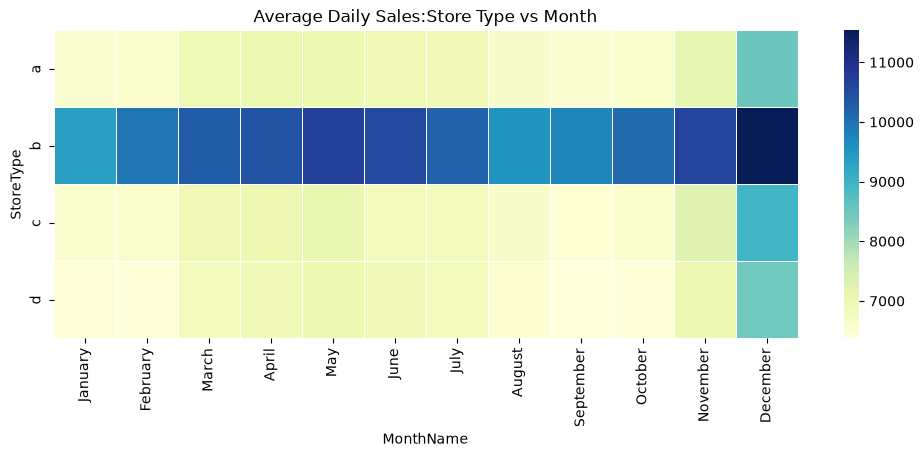

In [83]:
# Groupby and Multi-level Analysis
# Create a heatmap of sales by month and storetype

heatmap_data = df[df['Open']==1].pivot_table(
    values='Sales',
    index='StoreType',
    columns='MonthName',
    aggfunc='mean'
)[['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December' ]]

plt.figure(figsize=(12,4))
sns.heatmap(heatmap_data, annot=False, cmap='YlGnBu', linewidths=.5)
plt.title('Average Daily Sales:Store Type vs Month')
plt.savefig('heatmap.png')
plt.show()